In [1]:
import numpy as np
from scipy.optimize import brentq
from eigenstate_solving import BZ_proj
from model import square_lattice


def LHS_Kz(Kz, q, E, r_para, Q_para, lattice):
    """
    Solve for total momentum Kz from on-shell condition.
    F(Kz; q) = E1 + E2 - E.
    Uses np.hypot for numerical stability:
        hypot(a,b) = sqrt(a^2 + b^2).
    """
    abs_r_para = np.linalg.norm(r_para)
    abs_s_para = np.linalg.norm(BZ_proj(Q_para - r_para, lattice))

    k1z = 0.5 * Kz + q
    k2z = 0.5 * Kz - q

    E1 = np.hypot(abs_r_para, k1z)
    E2 = np.hypot(abs_s_para, k2z)

    return E1 + E2 - E


def q_bounds(E, r_para, Q_para, lattice):
    """
    Allowed q interval for propagating channels.
    Requires E >= m1 + m2.
    """
    abs_r_para = np.linalg.norm(r_para)
    abs_s_para = np.linalg.norm(BZ_proj(Q_para - r_para, lattice))
    if E < abs_r_para + abs_s_para:
        raise ValueError("No propagating two-photon channel: E < m1 + m2.")
    if (E - abs_r_para) ** 2 - abs_s_para**2 < 0 or (
        E - abs_s_para
    ) ** 2 - abs_r_para**2 < 0:
        raise ValueError("Negative value under square root in q_bounds.")
    q_min = -0.5 * np.sqrt((E - abs_r_para) ** 2 - abs_s_para**2)
    q_max = 0.5 * np.sqrt((E - abs_s_para) ** 2 - abs_r_para**2)

    return q_min, q_max


def solve_Kz(q, E, r_para, Q_para, lattice, xtol=1e-12, rtol=1e-12):
    """
    Solve F(Kz; q)=0 on the physical branch k1z,k2z >= 0.
    Returns Kz.
    """
    q_min, q_max = q_bounds(E, r_para, Q_para, lattice)

    if q < q_min - 1e-13 or q > q_max + 1e-13:
        raise ValueError(f"q={q} is outside allowed interval [{q_min}, {q_max}].")

    K_low = 2.0 * abs(q)
    K_high = E

    f_low = LHS_Kz(K_low, q, E, r_para, Q_para, lattice)
    f_high = LHS_Kz(K_high, q, E, r_para, Q_para, lattice)

    # Root can sit exactly at endpoint, especially near grazing thresholds.
    if abs(f_low) < xtol:
        return K_low
    if abs(f_high) < xtol:
        return K_high

    if f_low > 0 or f_high < 0:
        raise RuntimeError(f"Bad bracket: F(K_low)={f_low}, F(K_high)={f_high}.")

    return brentq(
        lambda K: LHS_Kz(K, q, E, r_para, Q_para, lattice),
        K_low,
        K_high,
        xtol=xtol,
        rtol=rtol,
        maxiter=100,
    )


In [2]:
from model import alpha, self_energy
from smatrix import create_self_energy_interpolator_numba

sigma_data = np.load("../../data/sigma_grid0f1a.npz")
kx = sigma_data["kx"]
ky = sigma_data["ky"]
sigma_grid = sigma_data["sigma_grid"]
sigma_func_period_numba = create_self_energy_interpolator_numba(
    kx, ky, sigma_grid, lattice=square_lattice
)
collective_lamb_shift = self_energy(
    0, 0, square_lattice.a, square_lattice.d, square_lattice.omega_e, alpha
).real
sigma_func_period = create_self_energy_interpolator_numba(
    kx, ky, sigma_grid, lattice=square_lattice
)
"""
k_para = np.array([50, 50])
E = square_lattice.omega_e

kz = np.sqrt(E**2 - np.hypot(k_para[0], k_para[1]) ** 2)
k = np.concatenate((k_para, np.array([kz])))

print(square_lattice.ge(k))
print(
    (
        -2
        * square_lattice.a**2
        * np.imag(sigma_func_period(k_para[0], k_para[1]))
        * (kz / E)
    )
    ** (1 / 2)
)
"""


'\nk_para = np.array([50, 50])\nE = square_lattice.omega_e\n\nkz = np.sqrt(E**2 - np.hypot(k_para[0], k_para[1]) ** 2)\nk = np.concatenate((k_para, np.array([kz])))\n\nprint(square_lattice.ge(k))\nprint(\n    (\n        -2\n        * square_lattice.a**2\n        * np.imag(sigma_func_period(k_para[0], k_para[1]))\n        * (kz / E)\n    )\n    ** (1 / 2)\n)\n'

In [4]:
import matplotlib.pyplot as plt

from smatrix.amplitudes import t_reg

"""
def W_profile_BM(
    r_para, q, p_para, E1, E, Q_para, lattice, sigma_func_period, eta
):
    Kz = solve_Kz(q, E, r_para, Q_para, lattice)
    rz = Kz / 2 + q
    sz = Kz / 2 - q

    Et = np.sqrt(np.linalg.norm(r_para) ** 2 + rz**2)

    J1 = 2 / ((rz / Et) + (sz / (E - Et)))
    # J2 = Et / rz
    # J3 = (E - Et) / sz
    s_para = BZ_proj(Q_para - r_para, lattice)
    # eigenvalue of this W state
    tt = t_reg(p_para, E1, lattice, sigma_func_period) * t_reg(
        BZ_proj(Q_para - p_para, lattice), E - E1, lattice, sigma_func_period
    )

    denom = (
        (
            Et
            - lattice.omega_e
            - np.conjugate(sigma_func_period(r_para[0], r_para[1]))
        )
        * (
            E
            - Et
            - lattice.omega_e
            - np.conjugate(sigma_func_period(s_para[0], s_para[1]))
        )
        - tt
        * (Et - lattice.omega_e - sigma_func_period(r_para[0], r_para[1]))
        * (E - Et - lattice.omega_e - sigma_func_period(s_para[0], s_para[1]))
        + 1j * eta
    )

    #    return J1 * J2 * J3 * 1 / denom
    return J1 / denom
"""


def W_profile_BM(r_para, q, p_para, E1, E, Q_para, lattice, sigma_func_period, eta):
    """Eta should be big enough to allow the grid to resolve the pole."""
    Kz = solve_Kz(q, E, r_para, Q_para, lattice)
    rz = Kz / 2 + q
    sz = Kz / 2 - q

    Et = np.sqrt(np.linalg.norm(r_para) ** 2 + rz**2)

    J1 = 2 / ((rz / Et) + (sz / (E - Et)))
    # J2 = Et / rz
    # J3 = (E - Et) / sz
    s_para = BZ_proj(Q_para - r_para, lattice)
    # eigenvalue of this W state
    tt = t_reg(p_para, E1, lattice, sigma_func_period) * t_reg(
        BZ_proj(Q_para - p_para, lattice), E - E1, lattice, sigma_func_period
    )

    D1 = Et - lattice.omega_e - sigma_func_period(r_para[0], r_para[1])
    D2 = E - Et - lattice.omega_e - sigma_func_period(s_para[0], s_para[1])
    denom = (
        D1
        * D2
        * (
            t_reg(r_para, Et, lattice, sigma_func_period)
            * t_reg(s_para, E - Et, lattice, sigma_func_period)
            - tt
            + 1j * eta
        )
    )

    return J1 / denom


def W_k_sp_grid(
    r_para,
    p_para,
    E1,
    E,
    Q_para,
    Zc,
    lattice,
    sigma_func_period,
    n_points,
    eta,
    eps=1e-10,
):
    q_min, q_max = q_bounds(E, r_para, Q_para, lattice)
    q_grid = np.linspace(q_min + eps, q_max - eps, n_points, endpoint=False)
    value_grid = np.zeros(len(q_grid), dtype=np.complex128)
    i = 0
    for q in q_grid:
        Kz = solve_Kz(q, E, r_para, Q_para, lattice)
        value_grid[i] = W_profile_BM(
            r_para, q, p_para, E1, E, Q_para, lattice, sigma_func_period, eta
        ) * np.exp(1j * Zc * Kz)  # positive sign for outgoing wave
        i += 1
    return q_grid, value_grid


In [10]:
from scipy.integrate import quad_vec

r_para = np.array([0, 0])
p_para = np.array([10, 10])
E1 = 203 / 2
E = 205
Q_para = np.array([0, 0])
sigma_func_period = sigma_func_period_numba
Zc = 10
q_min, q_max = q_bounds(E, r_para, Q_para, square_lattice)


def quad_FT(r_para, p_para, Zc, z, E1, E, Q_para, lattice, sigma_func_period,eta):
    def W_quad_integrand(q):
        return (
            W_profile_BM(
                r_para, q, p_para, E1, E, Q_para, lattice, sigma_func_period,eta
            )
            * np.exp(1j * Zc * solve_Kz(q, E, r_para, Q_para, lattice))
            * np.exp(1j * q * z)
        )

    q_min, q_max = q_bounds(E, r_para, Q_para, lattice)
    integral, integral_err = quad_vec(
        W_quad_integrand,
        q_min + 1e-10,
        q_max - 1e-10,
        epsabs=1e-9,
        epsrel=1e-9,
        limit=2000,
        quadrature="gk21",
    )

    return integral, integral_err

In discrete FFT, $\Delta q=2\times (q_{max}-q_{min})/n$, $L=\pi/\Delta q$, $\Delta z=2L/n$.

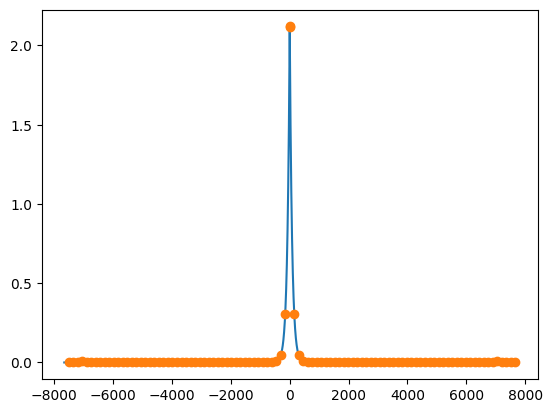

In [11]:
from scipy.fft import ifft

n_points = 2000000

q_grid, value_grid = W_k_sp_grid(
    r_para,
    p_para,
    E1,
    E,
    Q_para,
    Zc,
    square_lattice,
    sigma_func_period,
    n_points,
    eta=0.001,
)
dq = q_grid[1] - q_grid[0]
L = np.pi / dq  # Nyquist limit

z_grid = 2 * np.pi * np.fft.fftfreq(n_points, d=dq)

# value_grid_ifft = (q_max-q_min)*ifft(value_grid)
value_grid_ifft = n_points * dq * ifft(value_grid)
value_grid_ifft *= np.exp(1j * q_grid[0] * z_grid)

# Only compare where the q grid resolves exp(i q z) with several samples per period.
nyquist_z = np.pi / dq
min_samples_per_period = 8
resolved_z = 2 * np.pi / (min_samples_per_period * dq)
keep = np.abs(z_grid) <= resolved_z
trusted_idx = np.flatnonzero(keep)
sample_idx = trusted_idx[:: max(1, len(trusted_idx) // 100)]
z_sample = z_grid[sample_idx]

quad_result = []
quad_err = []
for z_val in z_sample:
    val, err = quad_FT(
        r_para,
        p_para,
        Zc,
        z_val,
        E1,
        E,
        Q_para,
        square_lattice,
        sigma_func_period,
        eta=0.001,
    )
    quad_result.append(val)
    quad_err.append(err)
quad_result = np.asarray(quad_result)
quad_err = np.asarray(quad_err)

plot_idx = np.argsort(z_grid[keep])
plt.plot(z_grid[keep][plot_idx], np.abs(value_grid_ifft[keep][plot_idx]))
plt.plot(z_sample, np.abs(quad_result), "o")
plt.show()

In [8]:
rng = np.random.default_rng(123)
random_idx = rng.choice(len(z_grid), size=20, replace=False)

def summation_at_z(z, q_grid, value_grid, dq):
    return dq * np.sum(value_grid * np.exp(1j * q_grid * z))

for idx in random_idx:
    z = z_grid[idx]
    fft_val = value_grid_ifft[idx]
    sum_val = summation_at_z(z, q_grid, value_grid, dq)
    print(idx, z, abs(fft_val - sum_val), abs(fft_val), abs(sum_val))

695601 21319.951136522028 8.861961841200948e-13 4.0060132114740415e-14 8.639317366432459e-13
1779785 -6749.5202559070485 3.3422873011926107e-13 7.92619087153485e-14 3.07591434137681e-13
898929 27551.890171524494 1.6904330861001645e-12 2.485472147529499e-14 1.7152834984861487e-12
368741 11301.79528498704 3.9140991353063146e-12 2.5551351132043923e-14 3.932652158653084e-12
1723815 -8464.98309323928 2.486318704763722e-13 9.462433136416806e-14 1.8538599803766202e-13
1846684 -4699.087017481303 4.61593424999201e-13 7.291294725744672e-14 3.9289899983169444e-13
510175 15636.702752116697 2.04181166373535e-12 6.599727512955159e-14 2.099437713096511e-12
553147 16953.78099127769 9.728729219300324e-13 7.671366964213343e-14 9.338989946532165e-13
440716 13507.806321559978 5.770979895132506e-12 5.721504967171001e-14 5.823260989755208e-12
1364691 -19472.020363099928 2.3102881194597183e-12 3.4239725459667186e-14 2.344302785826926e-12
667228 20450.327640298565 8.245602357452841e-13 7.099421464182385e-14 8

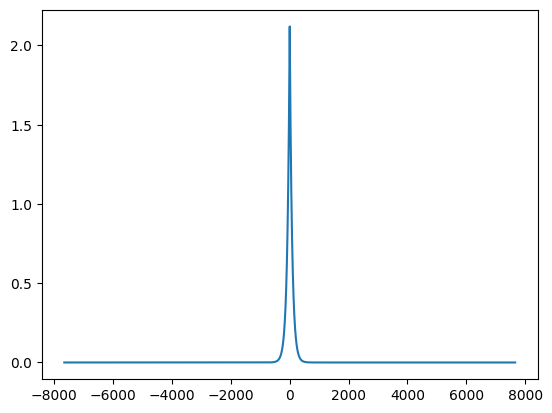

In [7]:
import matplotlib.pyplot as plt
plt.plot(z_grid[keep][plot_idx], np.abs(value_grid_ifft[keep][plot_idx]))

In [ ]:
def pole_loc(r_para, p_para, E1, E, Q_para, lattice, sigma_func_period):
    
    s_para = BZ_proj(Q_para - r_para, lattice)
    # eigenvalue of this W state
    tt = t_reg(p_para, E1, lattice, sigma_func_period) * t_reg(
        BZ_proj(Q_para - p_para, lattice), E - E1, lattice, sigma_func_period
    )

    def _denom(q):
        Kz = solve_Kz(q, E, r_para, Q_para, lattice)
        rz = Kz / 2 + q
        Et = np.sqrt(np.linalg.norm(r_para) ** 2 + rz**2)
        D1 = Et - lattice.omega_e - sigma_func_period(r_para[0], r_para[1])
        D2 = E - Et - lattice.omega_e - sigma_func_period(s_para[0], s_para[1])
        return D1 * D2 * (
            t_reg(r_para, Et, lattice, sigma_func_period)
            * t_reg(s_para, E - Et, lattice, sigma_func_period)
            - tt
        )

    q_min, q_max = q_bounds(E, r_para, Q_para, lattice)

    return brentq(_denom, q_min, q_max)



pole_loc(r_para, p_para, 204/2, E, Q_para, square_lattice, sigma_func_period)
    

    

/Users/ywan8652/research_project/2D_array/.venv/lib/python3.14/site-packages/scipy/optimize/_zeros_py.py:846: ComplexWarning: Casting complex values to real discards the imaginary part
  r = _zeros._brentq(f, a, b, xtol, rtol, maxiter, args, full_output, disp)


ValueError: f(a) and f(b) must have different signs